In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from datetime import datetime as dt


csv = pd.read_csv('ncr_ride_bookings.csv')
pd.set_option('display.max_columns', None)

#Data cleaining
csv['Date'] = pd.to_datetime(csv['Date'])

In [15]:
# Uber Ride Analytics Dataset – Questions (Generated by GPT-4)

# 1. Temporal & Seasonal Trends
# How does ride volume vary month to month? Are there seasonal peaks? ✅
# How does total miles traveled vary month to month?
# Which times of day see the highest number of rides?
# Do longer trips occur more often during specific times of day (morning commute, afternoon, evening)?
# Are ride patterns different on weekends compared to weekdays?
# Does trip purpose or category change depending on the day of the week?

# 2. Trip Purpose & Category Analysis
# What proportion of rides are business versus personal?
# Is there a trend over time in the proportion of business vs personal rides?
# Which trip purposes (e.g., meetings, meals, errands) are most common?
# Do certain trip purposes correlate with longer distances or specific times?
# How does trip purpose differ between business and personal rides?

# 3. Spatial Trends
# What are the most frequent pickup locations?
# What are the most frequent drop-off locations?
# Which origin–destination pairs are most common?
# Are there patterns in routes by time of day or trip purpose?

# 4. Duration and Distance
# What is the distribution of trip distances?
# What is the distribution of ride durations?
# Are there any outliers or extreme values in trip distances or durations?
# Do longer rides correlate with longer durations?
# Are there anomalies, like short trips with unusually long durations?

# 5. Derived Insights & Combinations
# Are business rides more likely during weekday mornings?
# Are personal rides concentrated in evenings or weekends?
# Which trip purposes correspond to longer distances?
# Are certain purposes more prevalent in certain months (e.g., more errands during holiday season)?
# How do weekend trips differ from weekday trips in terms of purpose and distance?

# 6. Visualization Ideas
# Bar charts: Ride counts per category, purpose, or time segment.
# Heatmaps: Trip counts or average miles by day of week vs hour of day.
# Time series line charts: Trends of rides or total miles over months.
# Boxplots or histograms: Distribution of distances and durations to identify outliers.
# Route maps: Visualize popular routes or pickup/drop-off hotspots if location data is available.

In [16]:
csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

In [17]:
csv.describe()

,Date,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,150000,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,2024-06-30 16:42:40.320000,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
min,2024-01-01 00:00:00,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,2024-03-31 00:00:00,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,2024-07-01 00:00:00,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,2024-09-30 00:00:00,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,2024-12-30 00:00:00,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000
std,NaN,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819


In [18]:
csv.sample(5)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
62741,2024-12-11,17:46:34,"""CNR3813713""",Completed,"""CID8986810""",Go Mini,Gurgaon Sector 56,IGI Airport,6.4,25.0,NaN,NaN,NaN,NaN,NaN,NaN,418.0,15.05,4.0,4.3,Cash
109915,2024-08-07,08:55:42,"""CNR1922658""",Completed,"""CID6099068""",Uber XL,Ramesh Nagar,INA Market,12.2,39.3,NaN,NaN,NaN,NaN,NaN,NaN,454.0,17.86,4.2,5.0,Cash
2255,2024-06-22,15:19:22,"""CNR5793101""",Completed,"""CID8897602""",Go Sedan,Malviya Nagar,Adarsh Nagar,13.0,43.7,NaN,NaN,NaN,NaN,NaN,NaN,1469.0,46.17,3.0,4.3,Cash
129781,2024-01-15,11:11:38,"""CNR8336769""",Completed,"""CID9941991""",Auto,Indirapuram,Dwarka Sector 21,12.6,35.4,NaN,NaN,NaN,NaN,NaN,NaN,1075.0,27.82,4.6,3.8,UPI
42173,2024-01-11,14:43:00,"""CNR2961069""",Completed,"""CID8009597""",Go Mini,Basai Dhankot,Munirka,14.4,16.3,NaN,NaN,NaN,NaN,NaN,NaN,2305.0,19.14,4.2,4.6,UPI


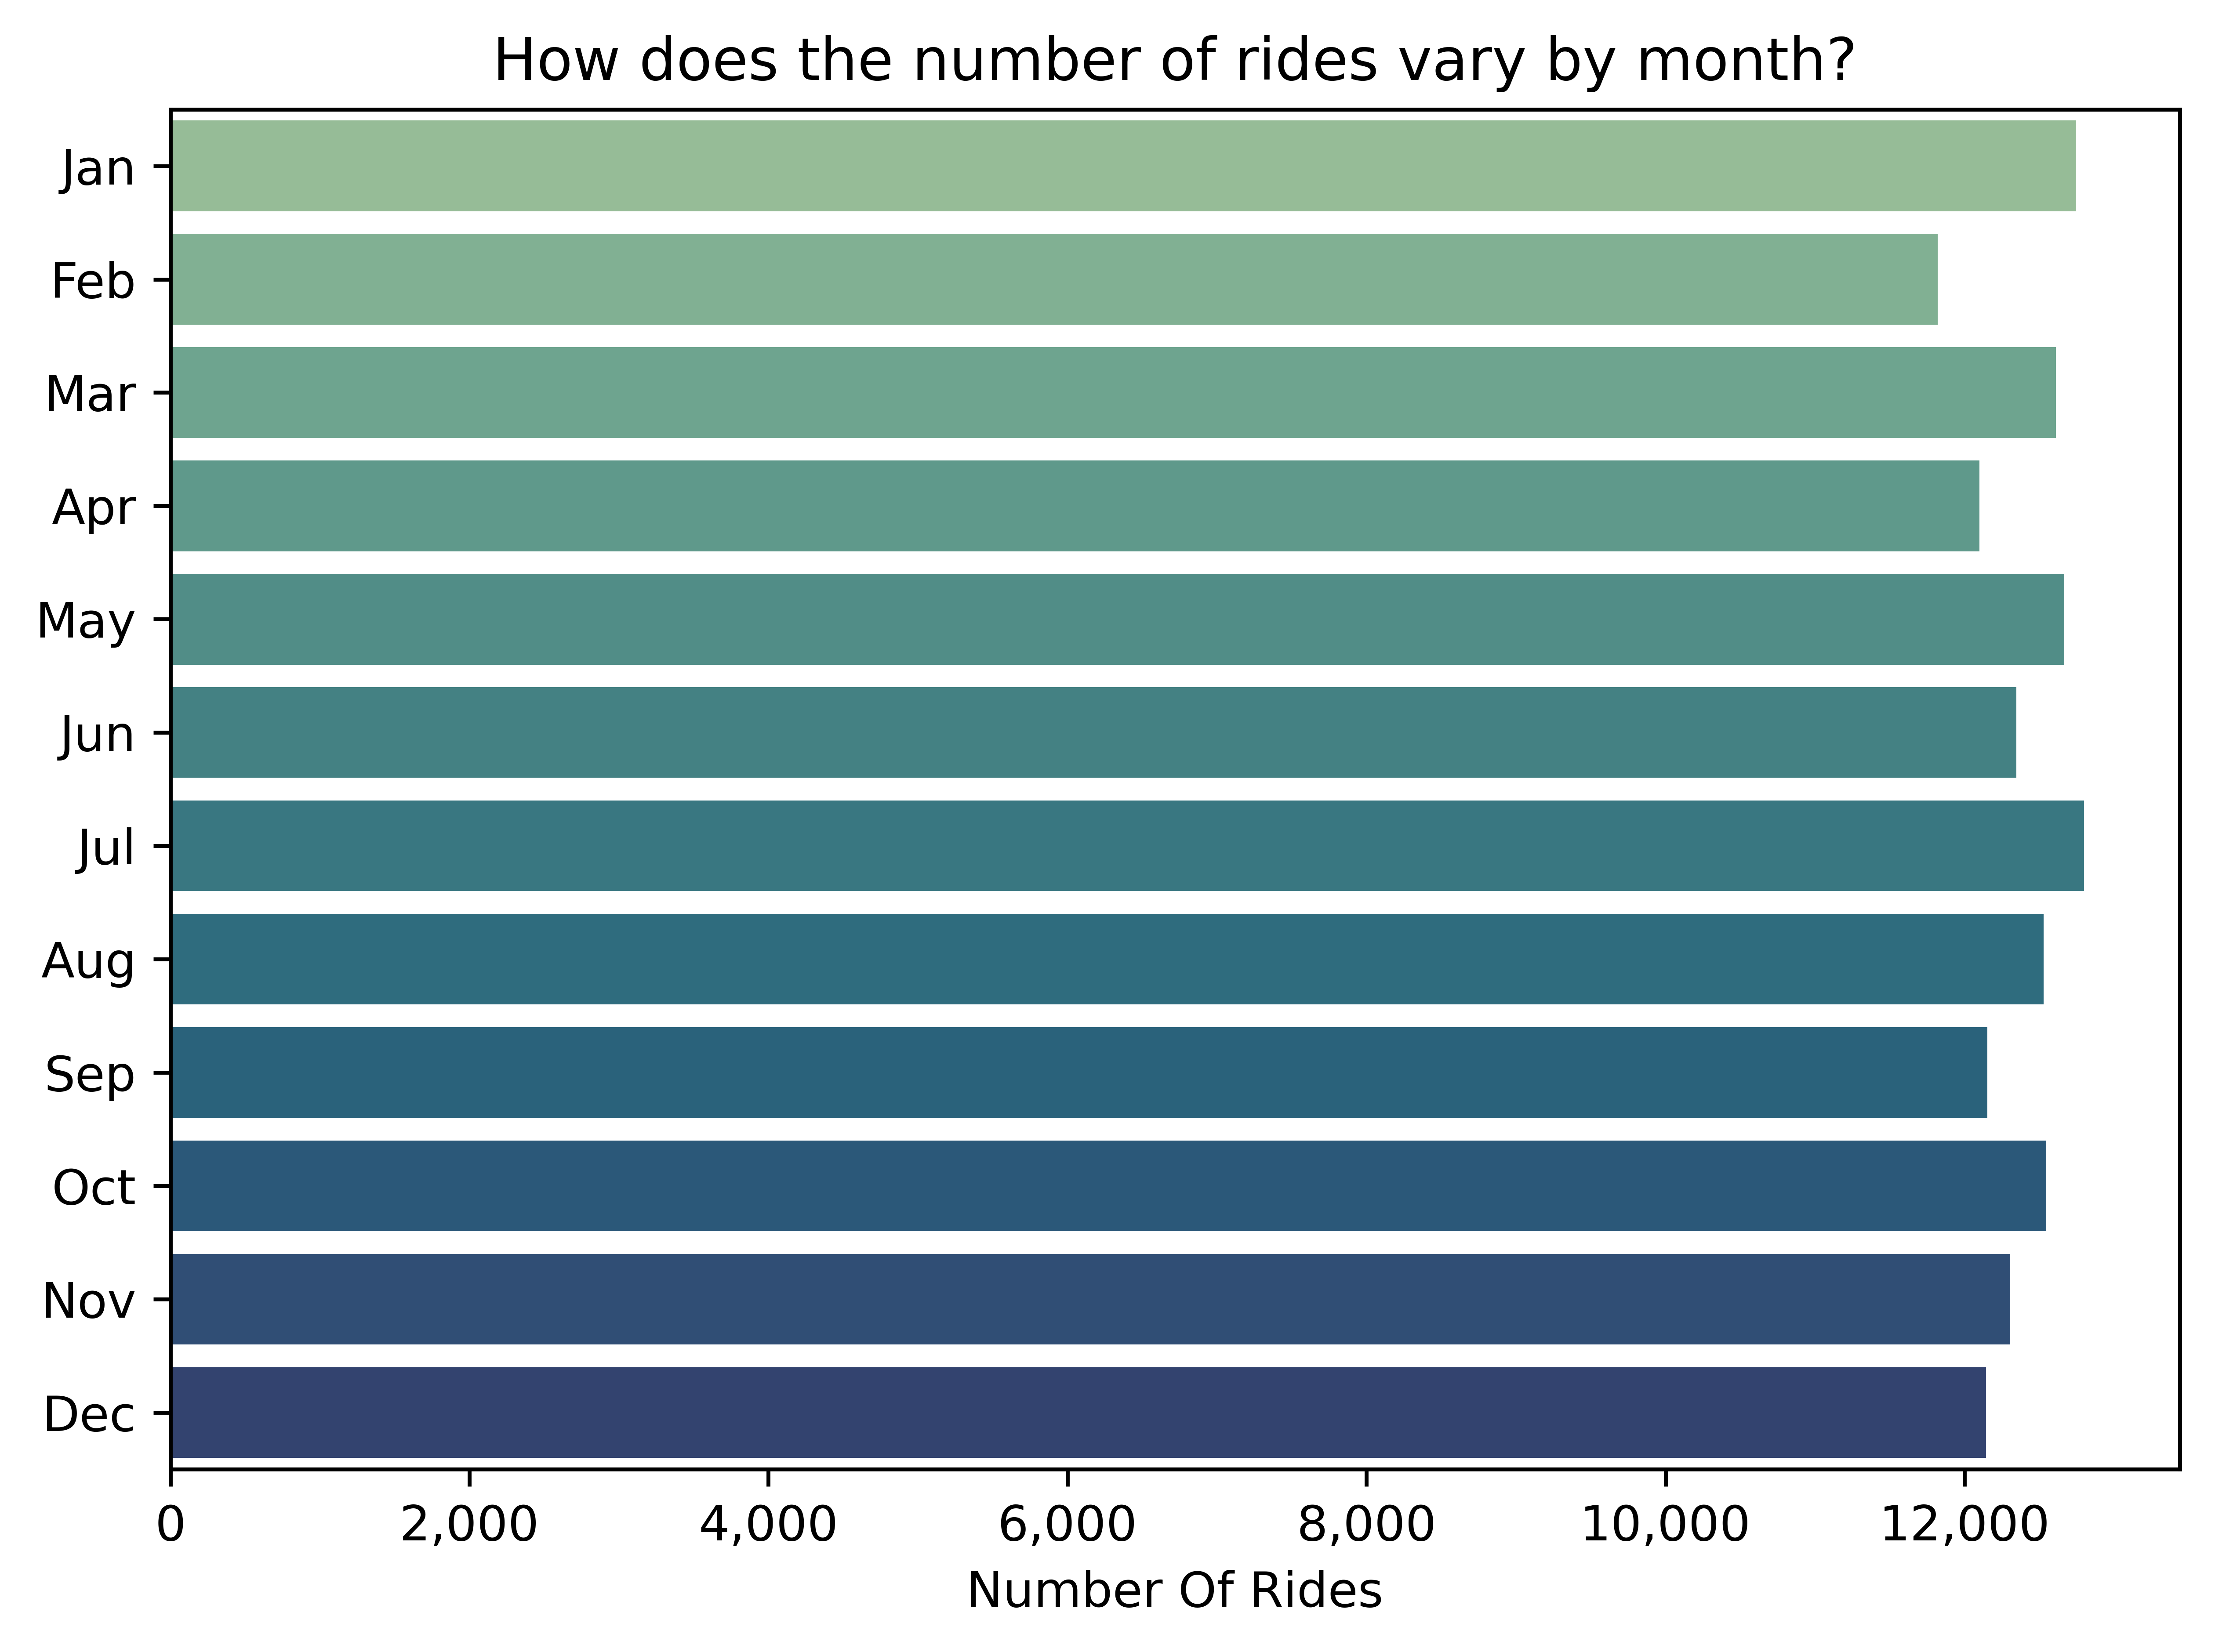

In [42]:
#Q1. How does ride volume vary month to month? Are there seasonal peaks?
csv_plot = csv.copy()
csv_plot['Month_no'] = csv_plot['Date'].dt.month
csv_plot.drop_duplicates(subset=['Booking ID'], inplace=True)
csv_plot['Month'] = csv_plot['Month_no'].apply(lambda x: pd.to_datetime(x, format='%m')).dt.strftime("%b")
csv_plot = csv_plot.groupby(['Month', 'Month_no'])['Booking ID'].count().reset_index()
csv_plot.rename(columns={'Booking ID': 'Count'}, inplace=True)
csv_plot.sort_values(by='Month_no', inplace=True)
csv_plot.drop('Month_no', axis=1, inplace=True)
csv_plot
sns.barplot(data=csv_plot, x='Count', y='Month', hue='Month', palette='crest')
plt.xlabel('Number Of Rides')
plt.ylabel('')
plt.title('How does the number of rides vary by month?')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()

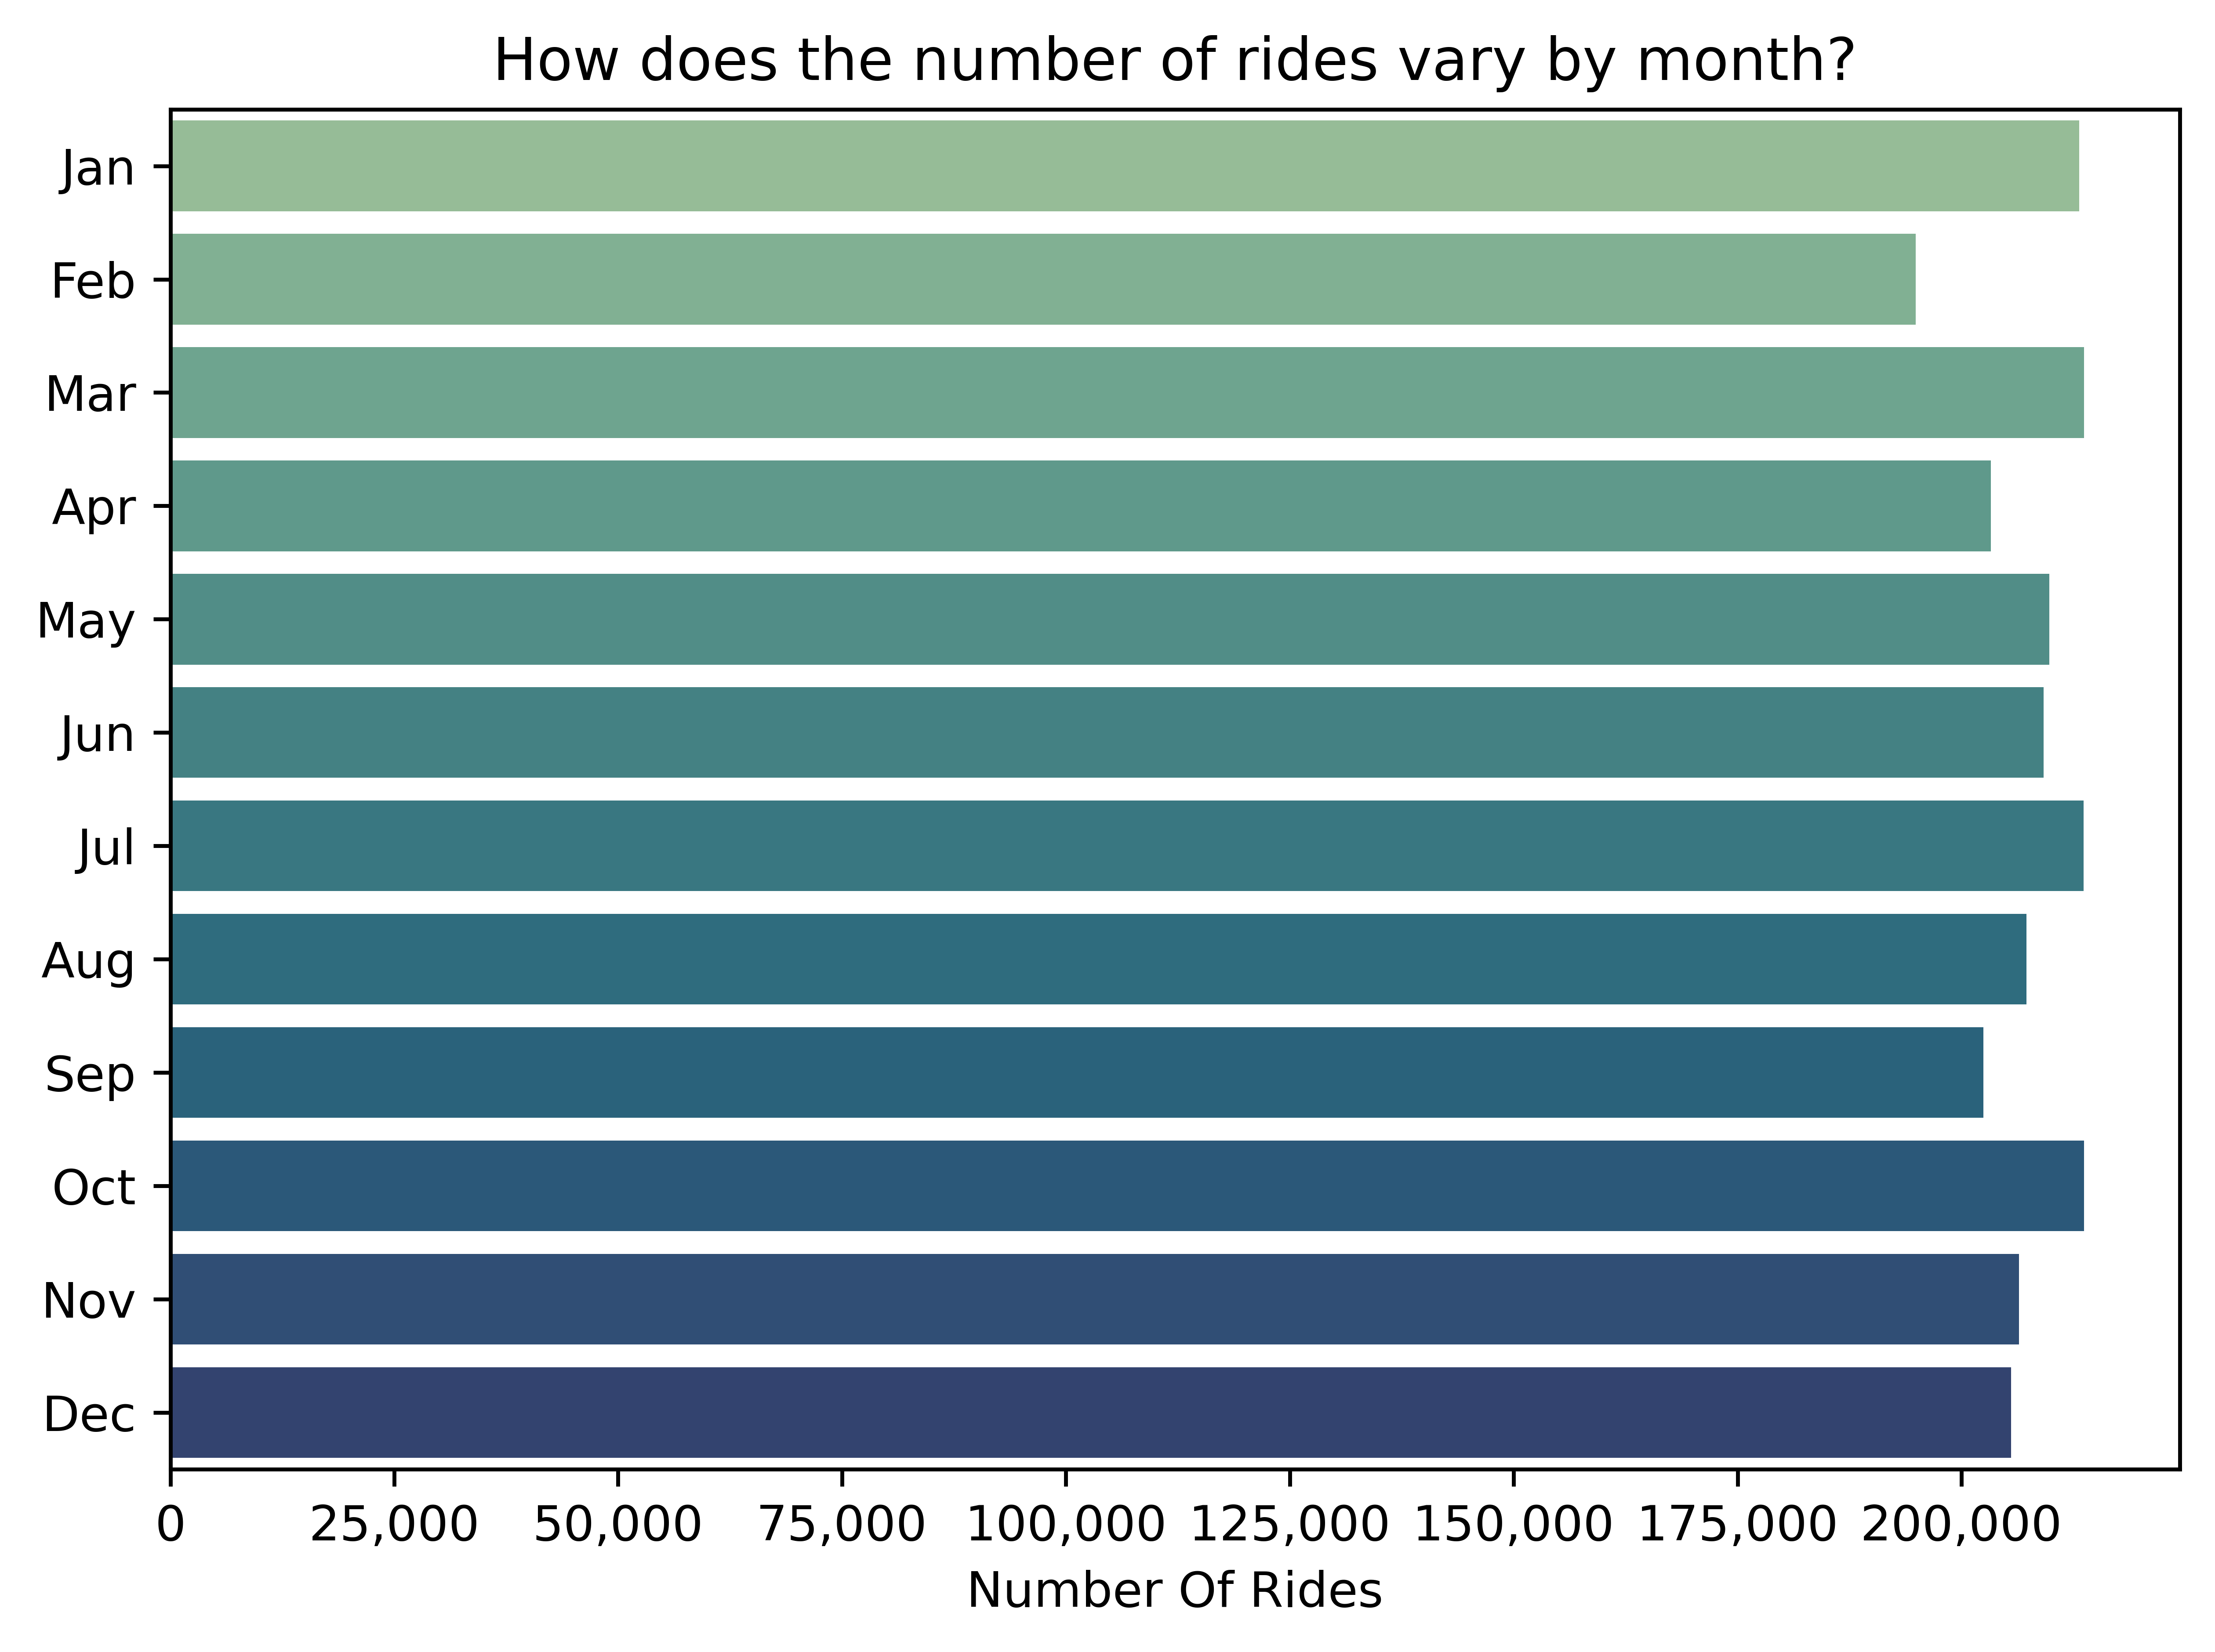

In [ ]:
# How does total miles traveled vary month to month?
csv_plot = csv.copy()
csv_plot['Month_no'] = csv_plot['Date'].dt.month
csv_plot.drop_duplicates(subset=['Booking ID'], inplace=True)
csv_plot['Month'] = csv_plot['Month_no'].apply(lambda x: pd.to_datetime(x, format='%m')).dt.strftime("%b")
csv_plot = csv_plot.groupby(['Month', 'Month_no'])['Ride Distance'].sum().reset_index()
csv_plot.rename(columns={'Ride Distance': 'Total Distance'}, inplace=True)
csv_plot.sort_values(by='Month_no', inplace=True)
csv_plot.drop('Month_no', axis=1, inplace=True)
csv_plot
sns.barplot(data=csv_plot, x='Total Distance', y='Month', hue='Month', palette='crest')
plt.xlabel('Number Of Rides')
plt.ylabel('')
plt.title('Total miles traveled over months')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()